In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
charts_folder = "Charts"

In [65]:
# Load dataset
df = pd.read_excel("3 year 21-22-23 SAC Agg.xlsx")

# df.head()
# df.columns
# df.info()

In [66]:
# Load dataset
intakes = pd.read_csv("Austin_Animal_Center_Intakes__10_01_2013_to_05_05_2025_.csv")

# intakes.head()
# intakes.columns
# intakes.info()

In [67]:
# Load dataset
outcomes = pd.read_csv("Austin_Animal_Center_Outcomes__10_01_2013_to_05_05_2025_.csv")

outcomes.head()
outcomes.columns
outcomes.info()

<class 'pandas.DataFrame'>
RangeIndex: 173775 entries, 0 to 173774
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Animal ID         173775 non-null  str  
 1   Date of Birth     173775 non-null  str  
 2   Name              123991 non-null  str  
 3   DateTime          173775 non-null  str  
 4   MonthYear         173775 non-null  str  
 5   Outcome Type      173729 non-null  str  
 6   Outcome Subtype   79660 non-null   str  
 7   Animal Type       173775 non-null  str  
 8   Sex upon Outcome  173774 non-null  str  
 9   Age upon Outcome  173766 non-null  str  
 10  Breed             173775 non-null  str  
 11  Color             173775 non-null  str  
dtypes: str(12)
memory usage: 15.9 MB


In [68]:
# List intake columns
feline_cols = [
    "Intake - Relinquished By Owner Total-Feline",
    "Intake - Stray At Large Total-Feline",
    "Intake - Transferred In Total-Feline",
    "Intake - Owner Intended Euthanasia Total-Feline",
    "Intakes - Other Intakes Total-Feline"
]

canine_cols = [
    "Intake - Relinquished By Owner Total-Canine",
    "Intake - Stray At Large Total-Canine",
    "Intake - Transferred In Total-Canine",
    "Intake - Owner Intended Euthanasia Total-Canine",
    "Intakes - Other Intakes Total-Canine"
]

# Total intake
df["Total Intake"] = df[feline_cols + canine_cols].sum(axis=1)

In [69]:
######## Austin Rates

# fix datetime
intakes["DateTime"] = pd.to_datetime(intakes["DateTime"])
outcomes["DateTime"] = pd.to_datetime(outcomes["DateTime"], errors="coerce", utc=True) #wasn't working without the force

# get year
intakes["Year"] = intakes["DateTime"].dt.year
outcomes["Year"] = outcomes["DateTime"].dt.year

years = [2021, 2022, 2023]

austin_list = []

for y in years:
    intake_count = intakes[intakes["Year"] == y].shape[0]
    
    outcomes_y = outcomes[outcomes["Year"] == y]
    
    adopt = outcomes_y[outcomes_y["Outcome Type"] == "Adoption"].shape[0]
    
    live = outcomes_y[outcomes_y["Outcome Type"].isin([
        "Adoption", "Return to Owner", "Transfer"
    ])].shape[0]
    
    euth = outcomes_y[outcomes_y["Outcome Type"] == "Euthanasia"].shape[0]
    
    austin_list.append({
        "Year": y,
        "Adoption Rate": adopt / intake_count,
        "Live Outcome Rate": live / intake_count,
        "Euthanasia Rate": euth / intake_count
    })

austin_df = pd.DataFrame(austin_list)

In [70]:
###### Texas Rates 

tx = df[df["State"] == "TX"].copy()

# Adoption
tx["Adoption"] = (
    tx["Live Outcome - Adoption Total-Feline"] +
    tx["Live Outcome - Adoption Total-Canine"]
)

# Live outcomes
tx["Live"] = (
    tx["Live Outcome - Adoption Total-Feline"] +
    tx["Live Outcome - Adoption Total-Canine"] +
    tx["Live Outcome - Returned To Owner Total-Feline"] +
    tx["Live Outcome - Returned To Owner Total-Canine"] +
    tx["Live Outcome - Transferred Out Total-Feline"] +
    tx["Live Outcome - Transferred Out Total-Canine"]
)

# Euthanasia
tx["Euthanasia"] = (
    tx["Other Outcome - Shelter Euthanasia Total-Feline"] +
    tx["Other Outcome - Shelter Euthanasia Total-Canine"]
)

tx["Adoption Rate"] = tx["Adoption"] / tx["Total Intake"]
tx["Live Outcome Rate"] = tx["Live"] / tx["Total Intake"]
tx["Euthanasia Rate"] = tx["Euthanasia"] / tx["Total Intake"]

tx_df = tx[tx["Year"].isin(years)][
    ["Year", "Adoption Rate", "Live Outcome Rate", "Euthanasia Rate"]
]

In [71]:
##### U.S. Rates

us = df.groupby("Year").sum(numeric_only=True).reset_index()

us["Adoption"] = (
    us["Live Outcome - Adoption Total-Feline"] +
    us["Live Outcome - Adoption Total-Canine"]
)

us["Live"] = (
    us["Live Outcome - Adoption Total-Feline"] +
    us["Live Outcome - Adoption Total-Canine"] +
    us["Live Outcome - Returned To Owner Total-Feline"] +
    us["Live Outcome - Returned To Owner Total-Canine"] +
    us["Live Outcome - Transferred Out Total-Feline"] +
    us["Live Outcome - Transferred Out Total-Canine"]
)

us["Euthanasia"] = (
    us["Other Outcome - Shelter Euthanasia Total-Feline"] +
    us["Other Outcome - Shelter Euthanasia Total-Canine"]
)

us["Adoption Rate"] = us["Adoption"] / us["Total Intake"]
us["Live Outcome Rate"] = us["Live"] / us["Total Intake"]
us["Euthanasia Rate"] = us["Euthanasia"] / us["Total Intake"]

us_df = us[us["Year"].isin(years)][
    ["Year", "Adoption Rate", "Live Outcome Rate", "Euthanasia Rate"]
]

In [ ]:
##### Combine
comparison = pd.DataFrame({
    "Metric": ["Adoption Rate", "Live Outcome Rate", "Euthanasia Rate"],
    "Austin": [
        austin_df["Adoption Rate"].mean(), # get avg across all years
        austin_df["Live Outcome Rate"].mean(),
        austin_df["Euthanasia Rate"].mean()
    ],
    "Texas": [
        tx_df["Adoption Rate"].mean(),
        tx_df["Live Outcome Rate"].mean(),
        tx_df["Euthanasia Rate"].mean()
    ],
    "US": [
        us_df["Adoption Rate"].mean(),
        us_df["Live Outcome Rate"].mean(),
        us_df["Euthanasia Rate"].mean()
    ]
})

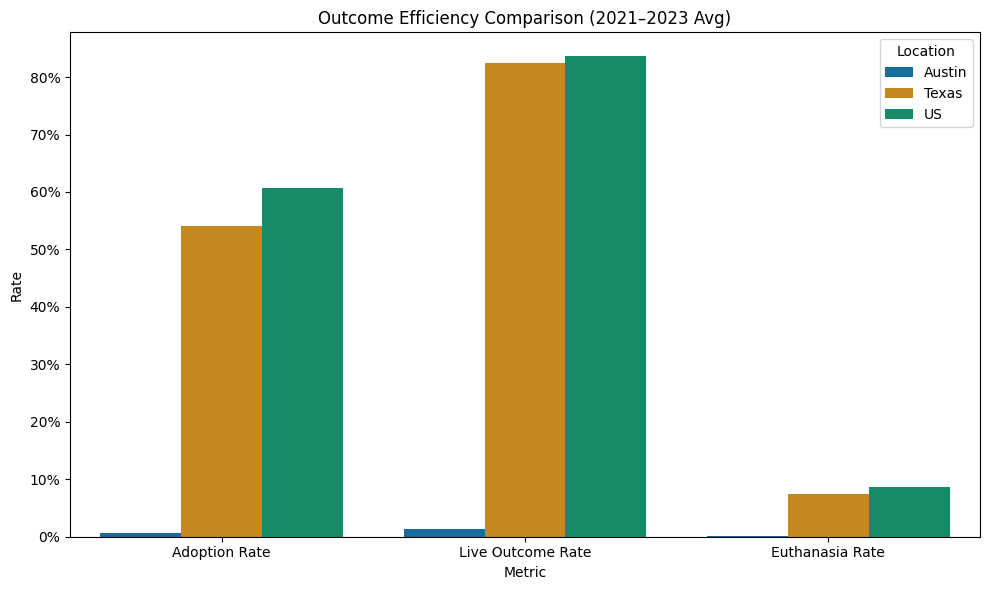

In [73]:
### MAke side-by-side bar charts 

plot_df = comparison.melt(
    id_vars="Metric",
    var_name="Location",
    value_name="Rate"
)

plt.figure(figsize=(10, 6))

sns.set_palette("colorblind")

sns.barplot(
    data=plot_df,
    x="Metric",
    y="Rate",
    hue="Location"
)

plt.title("Outcome Efficiency Comparison (2021–2023 Avg)")
plt.ylabel("Rate")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()

plt.savefig(
    f"{charts_folder}/outcome_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
print(comparison)

              Metric    Austin     Texas        US
0      Adoption Rate  0.005649  0.539985  0.607511
1  Live Outcome Rate  0.013509  0.824999  0.836086
2    Euthanasia Rate  0.000563  0.074210  0.085840


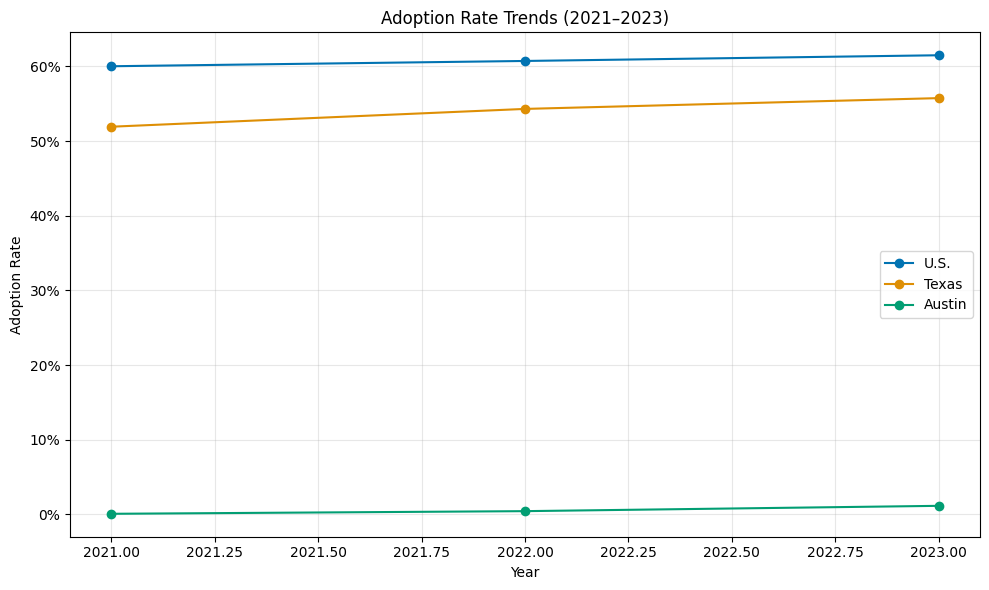

In [76]:

plt.figure(figsize=(10, 6))

sns.set_palette("colorblind")

# US
plt.plot(us_df["Year"], us_df["Adoption Rate"], marker='o', label="U.S.")

# Texas
plt.plot(tx_df["Year"], tx_df["Adoption Rate"], marker='o', label="Texas")

# Austin
plt.plot(austin_df["Year"], austin_df["Adoption Rate"], marker='o', label="Austin")

plt.title("Adoption Rate Trends (2021–2023)")
plt.ylabel("Adoption Rate")
plt.xlabel("Year")

plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{charts_folder}/compare_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()